## 🧙‍♂️ Lab 7: Magic Wand Digit Classification with TinyML

In this lab, you'll build a **real-time digit recognition system** using the **Arduino Nano 33 BLE Sense** and **TinyML** tools.

You will begin by training a **Convolutional Neural Network (CNN)** model to recognize digits (0–9) drawn in the air using motion sensors. After training, you'll compress the model using **int8 quantization** and deploy it to your Arduino. You’ll then test the baseline model on your device and evaluate its ability to recognize your gestures.

Next, you will **collect your own motion data** by drawing digits and saving the resulting `wanddata.json` file. Using this personalized dataset, you will fine-tune the model to adapt it to your unique gesture style. You will then re-quantize the fine-tuned model and deploy it again to observe improvements in recognition accuracy.

By the end of this lab, you will:
- Understand how to train and quantize CNNs for deployment on embedded systems.
- Practice real-time inference using motion sensor data.
- Learn the impact of **user-specific fine-tuning** on model performance.
- Explore the full lifecycle of a TinyML application: **data collection → training → deployment → inference**.

> ✨ **The goal** is to turn your Arduino Nano into a magic wand that can recognize digits drawn in the air — a powerful and fun demonstration of machine learning at the edge.


In [1]:
SAVED_MODEL_FILENAME = "saved_model.keras"
FLOAT_TFL_MODEL_FILENAME = "float_model.tfl"
QUANTIZED_TFL_MODEL_FILENAME = "quantized_model.tfl"
TFL_CC_MODEL_FILENAME = "magic_wand_model_data.cc"

## 🔧 Lab 7: Magic Wand Digit Classification using TinyML

In this lab, we'll train a compact neural network that can recognize digits (0–9) drawn in the air using a gesture sensor. We'll use a pre-collected dataset of digit strokes and convert them into 32×32 images that our model can learn from.

---

### 📁 Step 1: Setup and File Preparation

Before we begin training our model, we need to prepare the dataset and workspace.

#### 🧠 What This Does

- `!rm -rf magic_wand_digit_data`: Deletes any old version of the data folder if it exists.
- `!unzip magic_wand_digit_data.zip`: Extracts the zip file containing digit data.
- `!mv magic_wand_digit_data-* magic_wand_digit_data`: Renames the extracted folder to a simpler name.
- `!rm -rf magic_wand_digit_data.zip sample_data`: Cleans up unnecessary files.
- `!mkdir -p checkpoints`: Creates a folder where we'll later save our model during training.

This ensures a clean workspace and prepares everything you need to start working with the dataset.


In [2]:
!rm -rf magic_wand_digit_data
!unzip magic_wand_digit_data.zip
!mv magic_wand_digit_data-* magic_wand_digit_data
!rm -rf magic_wand_digit_data.zip sample_data
!mkdir -p checkpoints

Archive:  magic_wand_digit_data.zip
   creating: /Users/adityabhagwani/Documents/EE 446/Lab-7-Material/magic_wand_digit_data
  inflating: __MACOSX/._magic_wand_digit_data  
  inflating: magic_wand_digit_data/6.json  
  inflating: __MACOSX/magic_wand_digit_data/._6.json  
  inflating: magic_wand_digit_data/7.json  
  inflating: __MACOSX/magic_wand_digit_data/._7.json  
  inflating: magic_wand_digit_data/0.json  
  inflating: __MACOSX/magic_wand_digit_data/._0.json  
  inflating: magic_wand_digit_data/1.json  
  inflating: __MACOSX/magic_wand_digit_data/._1.json  
  inflating: magic_wand_digit_data/2.json  
  inflating: __MACOSX/magic_wand_digit_data/._2.json  
  inflating: magic_wand_digit_data/3.json  
  inflating: __MACOSX/magic_wand_digit_data/._3.json  
  inflating: magic_wand_digit_data/8.json  
  inflating: __MACOSX/magic_wand_digit_data/._8.json  
  inflating: magic_wand_digit_data/4.json  
  inflating: __MACOSX/magic_wand_digit_data/._4.json  
  inflating: magic_wand_digit_data/

---

### 📥 Step 2: Load the Stroke Data

Each digit drawing is stored as a series of `(x, y)` points inside JSON files. We load all strokes from the dataset using the provided code.

#### 🧠 What This Does

- `glob.glob(...)`: Finds all JSON files in the `magic_wand_digit_data` folder.
- For each file:
  - Reads the content and parses it as JSON.
  - Extracts each gesture stroke from the `"strokes"` list.
  - Adds the filename to each stroke (for debugging or traceability).
  - Appends the stroke to the `strokes` list.

After this step, the `strokes` list contains **all digit stroke data** for training and visualization.


In [3]:
import glob
import json

strokes = []
for filename in glob.glob("magic_wand_digit_data/*.json"):
  with open(filename, "r") as file:
    file_contents = file.read()
  file_data = json.loads(file_contents)
  for stroke in file_data["strokes"]:
    stroke["filename"] = filename
    strokes.append(stroke)

---

### 🖼️ Step 3: Visualize a Stroke

To better understand what a digit stroke looks like, we define a function `plot_stroke` that takes a single stroke dictionary and plots it using `matplotlib`.

#### 🧠 What This Does

- Extracts the sequence of `(x, y)` points from the `"strokePoints"` list.
- Uses `matplotlib` to:
  - Set up a wide figure for easy viewing.
  - Plot the stroke path.
  - Add labels to the axes and set visible bounds.
  - Display the digit label as the title.

This plot helps us confirm that strokes are correctly loaded and interpretable before training any models.

```python
plot_stroke(strokes[0])  # Try this to visualize the first stroke
```


In [4]:
import matplotlib.pyplot as plt

def plot_stroke(stroke):

  x_array = []
  y_array = []
  for coords in stroke["strokePoints"]:
    x_array.append(coords["x"])
    y_array.append(coords["y"])

  fig = plt.figure(figsize=(12.8, 4.8))
  fig.suptitle(stroke["label"])

  ax = fig.add_subplot(131)
  ax.set_xlabel('x')
  ax.set_ylabel('y')
  ax.set_xlim(-0.4, 0.4)
  ax.set_ylim(-0.4, 0.4)
  ax.plot(x_array, y_array)

  plt.show()

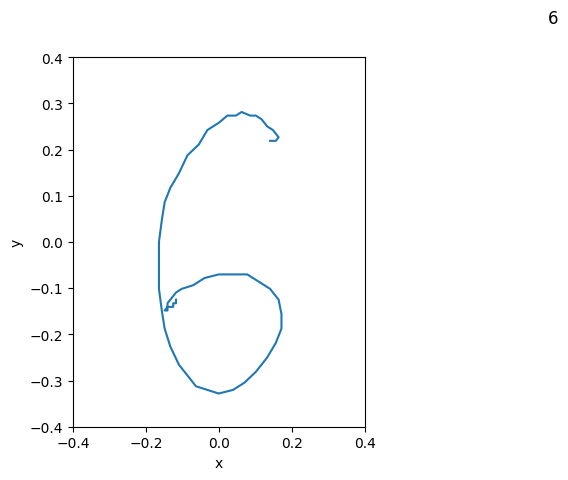

In [5]:
plot_stroke(strokes[11])

---

### 🖌️ Step 4: Convert Strokes into Images (Rasterization)

Now that we've visualized strokes, the next step is to convert these hand-drawn digit strokes into actual **image tensors** (like the ones you'd input into a CNN).

This process is called **rasterization**, and it converts a list of stroke coordinates into a 2D image (with RGB color channels) that we can feed into our model.

#### 🔧 Key Concepts

- **Fixed-Point Arithmetic**: To speed things up on tiny devices (like Arduino), we avoid using floating-point numbers and instead use integers scaled by a factor (`FIXED_POINT = 256`). This mimics how microcontrollers handle math.
- **Color Encoding**: We gradually color the stroke from red → green → blue to preserve the drawing order. This adds temporal info to our image.
- **Line Drawing**: Each pair of consecutive stroke points is connected using a line-drawing algorithm, and the pixel values along the line are filled in.

#### 🧩 Helper Functions

- `float_to_fp(a)`: Converts a float to fixed-point representation.
- `div_fp(a, b)` and `mul_fp(a, b)`: Do fixed-point division and multiplication.
- `round_fp_to_int(a)`: Converts fixed-point back to integer.
- `gate(a, min, max)`: Clamps value between `min` and `max`.

#### 📦 Final Output

- The function returns a `(height, width, 3)` NumPy array containing the **RGB image** of the drawn digit.

```python
raster = rasterize_stroke(stroke["strokePoints"], x_range=0.6, y_range=0.6, width=32, height=32)
```
---

### 📐 What are `x_range` and `y_range`?

- `x_range` and `y_range` define the **expected coordinate span** of the input strokes in the horizontal (x) and vertical (y) directions.
- These values help map the normalized stroke coordinates (which usually range between -0.3 and +0.3) to the corresponding pixel positions in the image grid.

#### Why do we need them?

Imagine your stroke data fits inside a square from -0.3 to +0.3 in both x and y axes. If we want to draw this stroke on a 32x32 image, we need to **scale and center** it properly. That’s where `x_range = 0.6` and `y_range = 0.6` come in — they ensure the entire stroke fits nicely within the image boundaries.

#### Summary

- `x_range = 0.6`: Total expected width of the stroke in normalized space
- `y_range = 0.6`: Total expected height of the stroke in normalized space

You can think of this as zooming out enough so that no part of the digit gets cut off when rasterized.

---

This rasterized output can now be saved as a PNG or directly used in model training!

---


In [6]:
import math
import numpy as np
import PIL

FIXED_POINT = 256

def mul_fp(a, b):
  return (a * b) / FIXED_POINT

def div_fp(a, b):
  if b == 0:
    b = 1
  return (a * FIXED_POINT) / b

def float_to_fp(a):
  return math.floor(a * FIXED_POINT)

def norm_to_coord_fp(a, range_fp, half_size_fp):
  a_fp = float_to_fp(a)
  norm_fp = div_fp(a_fp, range_fp)
  return mul_fp(norm_fp, half_size_fp) + half_size_fp

def round_fp_to_int(a):
  return math.floor((a + (FIXED_POINT / 2)) / FIXED_POINT)

def gate(a, min, max):
  if a < min:
    return min
  elif a > max:
    return max
  else:
    return a

def rasterize_stroke(stroke_points, x_range, y_range, width, height):
  num_channels = 3
  buffer_byte_count = height * width * num_channels
  buffer = bytearray(buffer_byte_count)

  width_fp = width * FIXED_POINT
  height_fp = height * FIXED_POINT
  half_width_fp = width_fp / 2
  half_height_fp = height_fp / 2
  x_range_fp = float_to_fp(x_range)
  y_range_fp = float_to_fp(y_range)

  t_inc_fp = FIXED_POINT / len(stroke_points)

  one_half_fp = (FIXED_POINT / 2)

  for point_index in range(len(stroke_points) - 1):
    start_point = stroke_points[point_index]
    end_point = stroke_points[point_index + 1]
    start_x_fp = norm_to_coord_fp(start_point["x"], x_range_fp, half_width_fp)
    start_y_fp = norm_to_coord_fp(-start_point["y"], y_range_fp, half_height_fp)
    end_x_fp = norm_to_coord_fp(end_point["x"], x_range_fp, half_width_fp)
    end_y_fp = norm_to_coord_fp(-end_point["y"], y_range_fp, half_height_fp)
    delta_x_fp = end_x_fp - start_x_fp
    delta_y_fp = end_y_fp - start_y_fp

    t_fp = point_index * t_inc_fp
    if t_fp < one_half_fp:
      local_t_fp = div_fp(t_fp, one_half_fp)
      one_minus_t_fp = FIXED_POINT - local_t_fp
      red = round_fp_to_int(one_minus_t_fp * 255)
      green = round_fp_to_int(local_t_fp * 255)
      blue = 0
    else:
      local_t_fp = div_fp(t_fp - one_half_fp, one_half_fp)
      one_minus_t_fp = FIXED_POINT - local_t_fp
      red = 0
      green = round_fp_to_int(one_minus_t_fp * 255)
      blue = round_fp_to_int(local_t_fp * 255)
    red = gate(red, 0, 255)
    green = gate(green, 0, 255)
    blue = gate(blue, 0, 255)

    if abs(delta_x_fp) > abs(delta_y_fp):
      line_length = abs(round_fp_to_int(delta_x_fp))
      if delta_x_fp > 0:
        x_inc_fp = 1 * FIXED_POINT
        y_inc_fp = div_fp(delta_y_fp, delta_x_fp)
      else:
        x_inc_fp = -1 * FIXED_POINT
        y_inc_fp = -div_fp(delta_y_fp, delta_x_fp)
    else:
      line_length = abs(round_fp_to_int(delta_y_fp))
      if delta_y_fp > 0:
        y_inc_fp = 1 * FIXED_POINT
        x_inc_fp = div_fp(delta_x_fp, delta_y_fp)
      else:
        y_inc_fp = -1 * FIXED_POINT
        x_inc_fp = -div_fp(delta_x_fp, delta_y_fp)
    for i in range(line_length + 1):
      x_fp = start_x_fp + (i * x_inc_fp)
      y_fp = start_y_fp + (i * y_inc_fp)
      x = round_fp_to_int(x_fp)
      y = round_fp_to_int(y_fp)
      if (x < 0) or (x >= width) or (y < 0) or (y >= height):
        continue
      buffer_index = (y * width * num_channels) + (x * num_channels)
      buffer[buffer_index + 0] = red
      buffer[buffer_index + 1] = green
      buffer[buffer_index + 2] = blue

  np_buffer = np.frombuffer(buffer, dtype=np.uint8).reshape(height, width, num_channels)

  return np_buffer

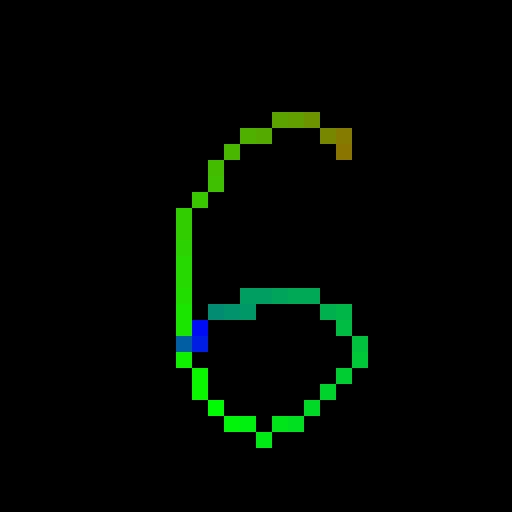

In [7]:
raster = rasterize_stroke(strokes[11]["strokePoints"], 0.5, 0.5, 32, 32)
PIL.Image.fromarray(raster).resize((512, 512), PIL.Image.NEAREST)

---

### 🖼️ Converting Stroke Data into Images with Augmentation

In this step, we convert each digit stroke into a **32×32 RGB image** and apply **data augmentation** to improve model generalization.

---

### 🔄 Function: `augment_points(...)`

This function adds random variations to the original stroke:
- **Translation:** Random shift in x and y directions.
- **Scaling:** Random resize (zoom in/out).
- **Rotation:** Random rotation (clockwise or counter-clockwise).

> ✅ This helps simulate real-world variations in handwriting.

---

### 🧹 Function: `ensure_empty_dir(...)`

- Deletes the directory if it already exists.
- Creates a clean, empty directory to store image files.
- Prevents leftover files from previous runs.

---

### 💾 Function: `save_strokes_as_images(...)`

This is the main function that:
1. Groups strokes by label.
2. Creates subfolders for each label (0–9).
3. Converts strokes to images using `rasterize_stroke(...)`.
4. Saves both the original and augmented images.

For each stroke:
- 1 original image is saved.
- `augment_count` additional images are generated using transformations.

> 💡 This prepares the dataset to be loaded later using `image_dataset_from_directory(...)`.


In [8]:
from pathlib import Path
import shutil

X_RANGE = 0.6
Y_RANGE = 0.6

def ensure_empty_dir(dirname):
  dirpath = Path(dirname)
  if dirpath.exists() and dirpath.is_dir():
    shutil.rmtree(dirpath)
  dirpath.mkdir()

def augment_points(points, move_range, scale_range, rotate_range):
  move_x = np.random.uniform(low=-move_range, high=move_range)
  move_y = np.random.uniform(low=-move_range, high=move_range)
  scale = np.random.uniform(low=1.0-scale_range, high=1.0+scale_range)
  rotate = np.random.uniform(low=-rotate_range, high=rotate_range)

  x_axis_x = math.cos(rotate) * scale
  x_axis_y = math.sin(rotate) * scale

  y_axis_x = -math.sin(rotate) * scale
  y_axis_y = math.cos(rotate) * scale

  new_points = []
  for point in points:
    old_x = point["x"]
    old_y = point["y"]
    new_x = (x_axis_x * old_x) + (x_axis_y * old_y) + move_x
    new_y = (y_axis_x * old_x) + (y_axis_y * old_y) + move_y
    new_points.append({"x": new_x, "y": new_y})

  return new_points

def save_strokes_as_images(strokes, root_folder, width, height, augment_count):
  ensure_empty_dir(root_folder)
  labels = set()
  for stroke in strokes:
    labels.add(stroke["label"].lower())
  for label in labels:
    label_path = Path(root_folder, label)
    ensure_empty_dir(label_path)

  label_counts = {}
  for stroke in strokes:
    points = stroke["strokePoints"]
    label = stroke["label"].lower()
    if label == "":
      raise Exception("Missing label for %s:%d" % (stroke["filename"], stroke["index"]))
    if label not in label_counts:
      label_counts[label] = 0
    label_count = label_counts[label]
    label_counts[label] += 1
    raster = rasterize_stroke(points, X_RANGE, Y_RANGE, width, height)
    image = PIL.Image.fromarray(raster)
    image.save(Path(root_folder, label, str(label_count) + ".png"))
    for i in range(augment_count):
      augmented_points = augment_points(points, 0.1, 0.1, 0.3)
      raster = rasterize_stroke(augmented_points, X_RANGE, Y_RANGE, width, height)
      image = PIL.Image.fromarray(raster)
      image.save(Path(root_folder, label, str(label_count) + "_a" + str(i) + ".png"))


---

### 📊 Splitting the Dataset: Train / Validation / Test

Before training a model, we need to **split our dataset** into three parts:

| Split         | Purpose                                  |
|---------------|-------------------------------------------|
| **Train**     | Used to train the model                  |
| **Validation**| Used to tune model parameters during training |
| **Test**      | Used to evaluate final performance        |

---

### 🔢 Split Ratios

We use the following percentage splits:
- **Train:** 80%
- **Validation:** 10%
- **Test:** 10%

---

### 🔄 Shuffling and Splitting

```python
np.random.shuffle(strokes)
```
This ensures that samples are randomly distributed across train/validation/test sets.

We compute the number of samples for each split using `math.floor` to avoid floating point issues.

---

### 🖼️ Saving the Images

We reuse the `save_strokes_as_images(...)` function to generate and save rasterized images:

```python
save_strokes_as_images(test_strokes, "test", IMAGE_WIDTH, IMAGE_HEIGHT, augment_count=10)
save_strokes_as_images(validation_strokes, "validation", IMAGE_WIDTH, IMAGE_HEIGHT, augment_count=0)
save_strokes_as_images(train_strokes, "train", IMAGE_WIDTH, IMAGE_HEIGHT, augment_count=10)
```

- **Train/Test:** Augment each sample with 10 variations.
- **Validation:** Only save the original sample (no augmentation).

---

> ✅ You will now have `train/`, `validation/`, and `test/` folders ready to use with TensorFlow's `image_dataset_from_directory(...)`.

---


In [9]:
IMAGE_WIDTH = 32
IMAGE_HEIGHT = 32

shuffled_strokes = strokes
np.random.shuffle(shuffled_strokes)

test_percentage = 10
validation_percentage = 10
train_percentage = 100 - (test_percentage + validation_percentage)

test_count = math.floor((len(shuffled_strokes) * test_percentage) / 100)
validation_count = math.floor((len(shuffled_strokes) * validation_percentage) / 100)
test_strokes = shuffled_strokes[0:test_count]
validation_strokes = shuffled_strokes[test_count:(test_count + validation_count)]
train_strokes = shuffled_strokes[(test_count + validation_count):]

save_strokes_as_images(test_strokes, "test", IMAGE_WIDTH, IMAGE_HEIGHT, 10)
save_strokes_as_images(validation_strokes, "validation", IMAGE_WIDTH, IMAGE_HEIGHT, 0)
save_strokes_as_images(train_strokes, "train", IMAGE_WIDTH, IMAGE_HEIGHT, 10)

---

### 🧹 Loading the Train and Validation Datasets

After creating the image folders (`train/` and `validation/`), we now use **TensorFlow's `image_dataset_from_directory`** utility to load the data into TensorFlow-friendly datasets.

---

### 🧠 `image_dataset_from_directory(...)`

This function:
- Loads images from subdirectories.
- Automatically infers the class labels based on subfolder names (e.g., `train/0`, `train/1`, ...).
- Resizes all images to `(32, 32)` and batches them.

---

### 🔁 Prefetching for Efficiency

We apply `.prefetch(buffer_size=32)` to enable asynchronous loading for better training speed.


---

> 🧠 Note: The `label_mode='categorical'` ensures labels are returned as one-hot encoded vectors (e.g., `[0, 0, 1, 0, 0, ...]` for class 2).

---


In [10]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import image_dataset_from_directory

validation_ds = image_dataset_from_directory(
    directory='validation',
    labels='inferred',
    label_mode='categorical',
    batch_size=32,
    image_size=(IMAGE_WIDTH, IMAGE_HEIGHT)).prefetch(buffer_size=32)

train_ds = image_dataset_from_directory(
    directory='train',
    labels='inferred',
    label_mode='categorical',
    batch_size=32,
    image_size=(IMAGE_WIDTH, IMAGE_HEIGHT)).prefetch(buffer_size=32)


Found 99 files belonging to 10 classes.
Found 8811 files belonging to 10 classes.


### 🔍 Previewing Training Data

Before training our model, it's important to visually confirm that the digit images have been correctly rasterized and categorized. By taking a small sample from the training dataset and displaying them, we can verify that:

- The stroke-to-image conversion worked correctly.
- Each image has the expected dimensions (32×32 with 3 color channels).
- Labels inferred from folder names are accurate.
- No corrupted or blank images are present.

This step ensures confidence in the quality of our training data before proceeding with model development and training.


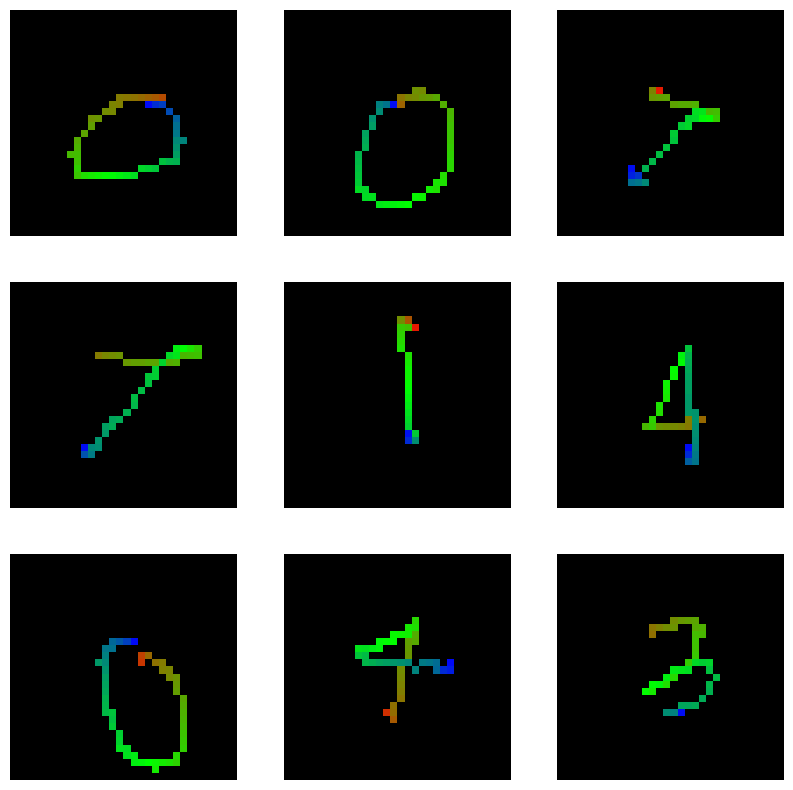

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.axis("off")

### 🧠 Designing a Compact CNN for Digit Classification

We will build a small but effective Convolutional Neural Network (CNN) to classify hand-drawn digits from rasterized wand strokes. The design balances accuracy and size so it can later be deployed on microcontrollers using TinyML techniques.

#### 🏗️ Model Architecture Overview

1. **Input Layer (32×32×3)**  
   The input image is rescaled to have pixel values between 0 and 1 using normalization.

2. **Convolutional Layer 1**  
   - Filters: 8  
   - Kernel size: 3×3  
   - Stride: 2  
   - Output: 16×16×8  
   - Purpose: Captures low-level patterns like edges.

3. **Convolutional Layer 2**  
   - Filters: 16  
   - Kernel size: 3×3  
   - Stride: 2  
   - Output: 8×8×16  
   - Purpose: Learns more abstract features.

4. **Convolutional Layer 3**  
   - Filters: 32  
   - Kernel size: 3×3  
   - Stride: 2  
   - Output: 4×4×32  
   - Purpose: Extracts deep feature representations.

5. **Flatten Layer**  
   - Converts the 3D output into a 1D vector of size 512 (4×4×32) to be fed into the dense layer.

6. **Dense Layer (Output Layer)**  
   - Units: 10 (one for each digit 0–9)  
   - Activation: Softmax  
   - Purpose: Outputs class probabilities.

This model has been designed to be small and fast, making it suitable for real-time inference on embedded devices.


In [12]:
from keras import layers


def make_model(input_shape=(32, 32, 3), num_classes=10):
    inputs = keras.Input(shape=input_shape)
    x = layers.Rescaling(1.0 / 255)(inputs)

    x = layers.Conv2D(8, 3, strides=2, padding="same", activation="relu")(x)  # 16x16
    x = layers.Conv2D(16, 3, strides=2, padding="same", activation="relu")(x)  # 8x8
    x = layers.Conv2D(32, 3, strides=2, padding="same", activation="relu")(x)  # 4x4

    x = layers.Flatten()(x)  # → 4*4*32 = 512
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return keras.Model(inputs, outputs)

### 🧩 Model Architecture Visualization

To better understand how our CNN processes input data, we can visualize the model structure using a diagram.

Each block in the diagram represents a different type of layer, showing:

- **Layer type** (e.g., Conv2D, Flatten, Dense)
- **Output shape** after that layer
- **Parameter count** for each layer

This helps us:
- Verify that the dimensions shrink as expected through the convolution layers.
- See how many parameters are being learned.
- Confirm that the output layer has 10 neurons (one for each digit class).

🖼️ Once you run the code to generate the diagram, take a moment to study how the image size is reduced and the number of features increases as we go deeper in the network.


In [13]:
model = make_model(input_shape=(IMAGE_WIDTH, IMAGE_HEIGHT, 3), num_classes=10)
keras.utils.plot_model(model, show_shapes=True)

You must install pydot (`pip install pydot`) and install graphviz (see instructions at https://graphviz.gitlab.io/download/) for plot_model to work.


### 🏋️ Training the CNN Model

We now compile and train our CNN using the training and validation datasets.

#### 🔧 Compilation Settings:
- **Optimizer**: Adam with a learning rate of `0.001` – helps adjust the weights efficiently during training.
- **Loss Function**: Categorical Crossentropy – used for multi-class classification problems with one-hot encoded labels.
- **Metrics**: Accuracy – tracks how many predictions match the true labels.

#### 📦 Checkpointing:
We use a callback to save the model at the end of each epoch. This way, we can restore a specific version later if needed.

#### 🕒 Training:
We train the model for **30 epochs**, using the validation set to monitor performance during training. You should observe both the training and validation accuracy improving over time (ideally!).


In [14]:
from keras import callbacks, optimizers


model.compile(
    optimizer=optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks = [
    callbacks.ModelCheckpoint("checkpoints/save_at_{epoch}.keras"),
]

model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=30,
    callbacks=callbacks,
)

Epoch 1/30
276/276 [==============================] - 2s 4ms/step - loss: 1.2013 - accuracy: 0.5978 - val_loss: 0.1867 - val_accuracy: 0.9697
Epoch 2/30
276/276 [==============================] - 1s 4ms/step - loss: 0.4002 - accuracy: 0.8821 - val_loss: 0.0694 - val_accuracy: 0.9899
Epoch 3/30
276/276 [==============================] - 1s 4ms/step - loss: 0.2309 - accuracy: 0.9337 - val_loss: 0.0471 - val_accuracy: 1.0000
Epoch 4/30
276/276 [==============================] - 1s 5ms/step - loss: 0.1687 - accuracy: 0.9512 - val_loss: 0.0396 - val_accuracy: 0.9899
Epoch 5/30
276/276 [==============================] - 1s 4ms/step - loss: 0.1293 - accuracy: 0.9624 - val_loss: 0.0274 - val_accuracy: 1.0000
Epoch 6/30
276/276 [==============================] - 1s 4ms/step - loss: 0.1046 - accuracy: 0.9706 - val_loss: 0.0376 - val_accuracy: 0.9899
Epoch 7/30
276/276 [==============================] - 1s 4ms/step - loss: 0.0807 - accuracy: 0.9766 - val_loss: 0.0249 - val_accuracy: 0.9899
Epoch 

### 🔍 Predicting with the Trained Model

To evaluate how well our trained model works on a single image, we define a `predict_image()` function.

#### 🧠 What It Does:
- Loads a `.png` image from a given file path and resizes it to `32x32`.
- Converts the image to a NumPy array and adds a batch dimension (because the model expects batches).
- Passes the image through the trained model to get prediction probabilities.
- Finds the index of the class with the highest probability (i.e., the predicted digit).
- Returns both the predicted class index and the confidence score (i.e., highest probability).

#### 🧪 Example:
We test this function on a digit image from the `test/7/2.png` file. You should see a predicted class (like 7) and a confidence score between 0 and 1.

This is helpful to evaluate individual predictions or build a simple classifier app using our trained model.


In [15]:
def predict_image(model, filename):
  img = keras.preprocessing.image.load_img(filename, target_size=(IMAGE_WIDTH, IMAGE_HEIGHT))
  img_array = keras.preprocessing.image.img_to_array(img)
  img_array = tf.expand_dims(img_array, 0)  # Create batch axis
  predictions = model.predict(img_array).flatten()
  predicted_label_index = np.argmax(predictions)
  predicted_score = predictions[predicted_label_index]
  return (predicted_label_index, predicted_score)

index, score = predict_image(model, "test/7/2.png")

print(index, score)


1/1 [==============================] - 0s 68ms/step
7 0.99997175


### ✅ Evaluating the Model on the Test Set

Now that we’ve trained the model, let’s see how well it performs on the test images!

#### 🧪 Evaluation Logic:
- We loop through each digit directory (0–9) inside the `test/` folder.
- For each image:
  - We use our `predict_image()` function to get the predicted label and confidence score.
  - If the model isn’t confident enough (i.e., score < 0.75), we discard that prediction.
  - If the prediction is correct, we count it as correct. Otherwise, we count it as a wrong prediction and display the image to visually inspect it.

#### 📊 Metrics Reported:
- **Correct Predictions**: Number of times the model guessed right with high confidence.
- **Wrong Predictions**: Number of times it guessed wrong (with confidence ≥ 0.75).
- **Discarded Samples**: Predictions with confidence < 0.75 (we skip these).
- **Accuracy**: Calculated only from the predictions that were confident enough.

This method gives us a better sense of how the model performs **when it's confident**, and also highlights which images are more challenging.


1/1 [==============================] - 0s 10ms/step
9 expected, 7 found with score 0.934746


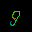

1/1 [==============================] - 0s 12ms/step
0 expected, 2 found with score 0.898432


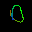

1/1 [==============================] - 0s 11ms/step
0 expected, 3 found with score 0.944179


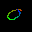

1/1 [==============================] - 0s 10ms/step
0 expected, 5 found with score 0.958515


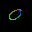

1/1 [==============================] - 0s 10ms/step
6 expected, 5 found with score 0.999837


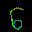

1/1 [==============================] - 0s 10ms/step
6 expected, 5 found with score 0.991380


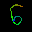

1/1 [==============================] - 0s 10ms/step
5 expected, 1 found with score 0.999516


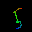

1/1 [==============================] - 0s 10ms/step
5 expected, 1 found with score 0.998542


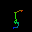

1/1 [==============================] - 0s 11ms/step
99.3% correct (N=1076, 13 unknown)


In [16]:
from IPython.display import Image, display

SCORE_THRESHOLD = 0.75

correct_count = 0
wrong_count = 0
discarded_count = 0
for label_dir in glob.glob("test/*"):
  label = int(label_dir.replace("test/", ""))
  for filename in glob.glob(label_dir + "/*.png"):
    index, score = predict_image(model, filename)
    if score < SCORE_THRESHOLD:
      discarded_count += 1
      continue
    if index == label:
      correct_count += 1
    else:
      wrong_count += 1
      print("%d expected, %d found with score %f" % (label, index, score))
      display(Image(filename=filename))

correct_percentage = (correct_count / (correct_count + wrong_count)) * 100
print("%.1f%% correct (N=%d, %d unknown)" % (correct_percentage, (correct_count + wrong_count), discarded_count))

### 💾 Saving the Trained Model

Once training is complete, it's important to **save the model** so that we can reuse it later without retraining.

We use the following command to save the entire model (including its architecture, weights, and training configuration) into a single file:

```python
model.save(SAVED_MODEL_FILENAME)
```

You can later reload this saved model using:

```python
loaded_model = keras.models.load_model(SAVED_MODEL_FILENAME)
```

This is especially useful when deploying the model, fine-tuning it later, or sharing it with others.


In [17]:
model.save(SAVED_MODEL_FILENAME)

### 📦 Converting the Model to TensorFlow Lite (TFLite)

To deploy our trained model on embedded devices like the **Arduino Nano 33 BLE Sense**, we need to convert it into the **TensorFlow Lite** format. Below are the two main steps:

---

#### 🔹 Step 1: Float Model (No Compression)

First, we convert the saved Keras model to a basic `.tflite` format **without quantization**.

- This version still uses floating-point weights.
- It’s not optimized for embedded devices but can help us test functionality.

---

#### 🔹 Step 2: Full Integer Quantization (int8)

To make the model small and fast enough for embedded devices, we apply **full integer quantization**:

- All model weights and activations are quantized to `int8`.
- This significantly reduces model size and speeds up inference.

##### 🧪 Representative Dataset

To help TensorFlow Lite understand the range of values in our input data, we provide a **representative dataset** from our test images. This is used during quantization to calibrate the model accurately.

```python
def representative_dataset():
    for filename in glob.glob("test/*/*.png"):
        img = keras.preprocessing.image.load_img(filename, target_size=(IMAGE_WIDTH, IMAGE_HEIGHT))
        img_array = keras.preprocessing.image.img_to_array(img)
        img_array = tf.expand_dims(img_array, 0)
        yield [img_array]
```

---

#### 💾 Saving the Models

After conversion:
- The **float model** is saved as `.tflite` (used for quick testing).
- The **quantized model** is saved as `.tflite` and ready for deployment to Arduino.

Now you’re ready to deploy your TinyML model!


In [18]:
input_shape = [1, 32, 32, 3]

loaded_model = tf.keras.models.load_model(SAVED_MODEL_FILENAME)

run_model = tf.function(lambda x: loaded_model(x))
concrete_func = run_model.get_concrete_function(
    tf.TensorSpec(input_shape, dtype=loaded_model.input.dtype)
)

converter = tf.lite.TFLiteConverter.from_concrete_functions([concrete_func])
model_no_quant_tflite = converter.convert()


# Save the model to disk
open(FLOAT_TFL_MODEL_FILENAME, "wb").write(model_no_quant_tflite)

def representative_dataset():
  for filename in glob.glob("test/*/*.png"):
    img = keras.preprocessing.image.load_img(filename, target_size=(IMAGE_WIDTH, IMAGE_HEIGHT))
    img_array = keras.preprocessing.image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)  # Create batch axis      for images, labels in train_ds.take(1):
    yield([img_array])
# Set the optimization flag.
converter.optimizations = [tf.lite.Optimize.DEFAULT]
# Enforce integer only quantization
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8
# Provide a representative dataset to ensure we quantize correctly.
converter.representative_dataset = representative_dataset
model_tflite = converter.convert()

# Save the model to disk
open(QUANTIZED_TFL_MODEL_FILENAME, "wb").write(model_tflite)

2026-05-14 18:14:11.013666: I tensorflow/core/grappler/devices.cc:75] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
2026-05-14 18:14:11.014609: I tensorflow/core/grappler/clusters/single_machine.cc:361] Starting new session
2026-05-14 18:14:11.061866: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-14 18:14:11.061880: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-14 18:14:11.144733: I tensorflow/compiler/mlir/lite/flatbuffer_export.cc:2245] Estimated count of arithmetic ops: 0.420 M  ops, equivalently 0.210 M  MACs
2026-05-14 18:14:11.156824: I tensorflow/core/grappler/devices.cc:75] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
2026-05-14 18:14:11.156884: I tensorflow/core/grappler/clusters

15928

### 🔍 Making Predictions with the TFLite Model

Once we have our quantized `.tflite` model, we need a way to **run inference** on new input images using TensorFlow Lite.

This function handles that:

---

#### 🧠 How It Works

1. **Preprocess Input**:
   - Load the image from a `.png` file.
   - Resize it to the input size expected by the model (e.g., 32x32).
   - Expand the batch dimension to make it shape `(1, 32, 32, 3)`.

2. **Initialize TFLite Interpreter**:
   - Load the `.tflite` model into memory.
   - Allocate tensors and prepare for inference.

3. **Quantize Input** *(if needed)*:
   - If the model expects `int8` input, we scale and shift the image values accordingly using the quantization parameters stored in the model.

4. **Run Inference**:
   - Feed the preprocessed image into the model.
   - Run the model to get predictions.

5. **Dequantize Output** *(if needed)*:
   - If the output is quantized, convert the result back to floating point for interpretation.

6. **Return Prediction**:
   - The function returns:
     - The **predicted class index** (e.g., 7),
     - The **confidence score** (probability for that class).

---

This function is essential for evaluating the TFLite model on unseen test images or real-time inputs.


In [19]:
def predict_tflite(tflite_model, filename):
  img = keras.preprocessing.image.load_img(filename, target_size=(IMAGE_WIDTH, IMAGE_HEIGHT))
  img_array = keras.preprocessing.image.img_to_array(img)
  img_array = tf.expand_dims(img_array, 0)

  # Initialize the TFLite interpreter
  interpreter = tf.lite.Interpreter(model_content=tflite_model)
  interpreter.allocate_tensors()

  input_details = interpreter.get_input_details()[0]
  output_details = interpreter.get_output_details()[0]

  # If required, quantize the input layer (from float to integer)
  input_scale, input_zero_point = input_details["quantization"]
  if (input_scale, input_zero_point) != (0.0, 0):
    img_array = np.multiply(img_array, 1.0 / input_scale) + input_zero_point
    img_array = img_array.astype(input_details["dtype"])

  # Invoke the interpreter
  interpreter.set_tensor(input_details["index"], img_array)
  interpreter.invoke()
  pred = interpreter.get_tensor(output_details["index"])[0]

  # If required, dequantized the output layer (from integer to float)
  output_scale, output_zero_point = output_details["quantization"]
  if (output_scale, output_zero_point) != (0.0, 0):
    pred = pred.astype(np.float32)
    pred = np.multiply((pred - output_zero_point), output_scale)

  predicted_label_index = np.argmax(pred)
  predicted_score = pred[predicted_label_index]
  return (predicted_label_index, predicted_score)

In [20]:
predict_tflite(model_no_quant_tflite, "test/7/2.png")

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


(7, 0.99997175)

In [21]:
predict_tflite(model_tflite, "test/0/5.png")

(0, 0.99609375)

### ✅ Evaluating the Quantized TFLite Model

Once we've converted our trained Keras model to a quantized `.tflite` version, it's important to check how well it performs on real data.

---

#### 🧪 Evaluation Workflow

This evaluation loop goes through every labeled image in the `test/` directory and checks how well the TFLite model performs:

1. **Loop Through Test Images**:
   - The folder `test/` contains subfolders named `0`, `1`, ..., `9`.
   - Each subfolder contains images belonging to that digit class.

2. **Run Inference**:
   - For each image, we use our `predict_tflite()` function to get the predicted class and a confidence score.

3. **Apply Confidence Threshold**:
   - If the confidence score is **below 0.75**, the prediction is discarded as "unsure".

4. **Track Results**:
   - If the predicted label matches the true label → ✅ Correct
   - If the labels don't match → ❌ Wrong
   - If the confidence is too low → 🚫 Discarded

5. **Print Incorrect Predictions**:
   - For every wrong prediction, the image is displayed along with the expected and predicted label.

6. **Final Statistics**:
   - We compute and print:
     - The overall classification **accuracy** on accepted predictions.
     - The **number of discarded predictions** due to low confidence.

---

This step mimics how your model will behave in real-world deployment: you may want to ignore low-confidence outputs to avoid making bad decisions.


9 expected, 7 found with score 0.957031


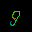

0 expected, 2 found with score 0.898438


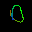

0 expected, 3 found with score 0.984375


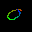

0 expected, 5 found with score 0.949219


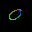

6 expected, 5 found with score 0.996094


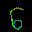

6 expected, 5 found with score 0.992188


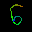

5 expected, 1 found with score 0.996094


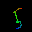

5 expected, 1 found with score 0.996094


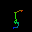

99.3% correct (N=1078, 11 unknown)


In [22]:
from IPython.display import Image, display

correct_count = 0
wrong_count = 0
discarded_count = 0
for label_dir in glob.glob("test/*"):
  label = int(label_dir.replace("test/", ""))
  for filename in glob.glob(label_dir + "/*.png"):
    index, score = predict_tflite(model_tflite, filename)
    if score < 0.75:
      discarded_count += 1
      continue
    if index == label:
      correct_count += 1
    else:
      wrong_count += 1
      print("%d expected, %d found with score %f" % (label, index, score))
      display(Image(filename=filename))

correct_percentage = (correct_count / (correct_count + wrong_count)) * 100

print("%.1f%% correct (N=%d, %d unknown)" % (correct_percentage, (correct_count + wrong_count), discarded_count))

### 📦 Comparing Model Sizes

When deploying TinyML models to embedded devices, model size is **just as important** as accuracy. Smaller models:
- Require less memory (both Flash and RAM)
- Load and run faster on resource-constrained hardware
- Are more energy efficient for edge inference

---

#### 🧮 Model Size Comparison

We compare the storage size of three versions of our model:

| Model                     | Size         | Reduction              |
|--------------------------|--------------|------------------------|
| TensorFlow               | Large        |                        |
| TensorFlow Lite          | Smaller      | Reduced from TF model  |
| TensorFlow Lite Quantized| Smallest     | Reduced from TFL model |

---

This analysis helps us see the **impact of quantization**:
- Quantized models use **8-bit integers** instead of 32-bit floats.
- They retain similar accuracy while being **much smaller**.

This tradeoff is crucial when preparing your models for real-world deployment on microcontrollers like the Arduino Nano 33 BLE Sense.


In [23]:
import os
import pandas as pd

# Function to calculate directory size (for future use with directories)
def get_dir_size(dir):
    size = 0
    for f in os.scandir(dir):
        if f.is_file():
            size += f.stat().st_size
        elif f.is_dir():
            size += get_dir_size(f.path)
    return size

# Calculate size of individual files
size_tf = os.path.getsize(SAVED_MODEL_FILENAME)  # Use os.path.getsize for files
size_no_quant_tflite = os.path.getsize(FLOAT_TFL_MODEL_FILENAME)
size_tflite = os.path.getsize(QUANTIZED_TFL_MODEL_FILENAME)

# Compare size
df = pd.DataFrame.from_records(
    [["TensorFlow", f"{size_tf} bytes", ""],
     ["TensorFlow Lite", f"{size_no_quant_tflite} bytes", f"(reduced by {size_tf - size_no_quant_tflite} bytes)"],
     ["TensorFlow Lite Quantized", f"{size_tflite} bytes", f"(reduced by {size_no_quant_tflite - size_tflite} bytes)"]],
    columns=["Model", "Size", "Reduction"], index=["Model"])

# Display the dataframe
print(df)



                                   Size                  Reduction
Model                                                             
TensorFlow                 171722 bytes                           
TensorFlow Lite             47412 bytes  (reduced by 124310 bytes)
TensorFlow Lite Quantized   15928 bytes   (reduced by 31484 bytes)


### 🛠️ Converting the Quantized Model to C Format

To run our quantized model on a microcontroller, we need to convert it into a format that the embedded device can understand — a C source file.

#### 🔄 Steps:
1. **Convert `.tflite` to `.cc`**:
   - We use the `xxd` utility to generate a C array from the quantized TFLite model.
   - This array can be compiled into your Arduino sketch or other microcontroller firmware.

2. **Rename the model variable**:
   - We replace the default variable name (based on the file name) with a consistent name: `g_magic_wand_model_data`.
   - This naming convention makes it easier to reference in the Arduino `.ino` file.

> 📝 This `.cc` file is now ready to be included in your embedded firmware project for deployment on devices like the Arduino Nano 33 BLE Sense.


In [24]:
# Install xxd if it is not available
!apt-get update && apt-get -qq install xxd
# Convert to a C source file, i.e, a TensorFlow Lite for Microcontrollers model
!xxd -i {QUANTIZED_TFL_MODEL_FILENAME} > {TFL_CC_MODEL_FILENAME}
# Update variable names
REPLACE_TEXT = QUANTIZED_TFL_MODEL_FILENAME.replace('/', '_').replace('.', '_')
!sed -i 's/'{REPLACE_TEXT}'/g_magic_wand_model_data/g' {TFL_CC_MODEL_FILENAME}

zsh:1: command not found: apt-get
sed: 1: "magic_wand_model_data.cc": invalid command code m


### 📄 Previewing the C Source File

The command below only prints the **last few lines** of the generated `.cc` file containing the quantized model in hexadecimal format.

> 🔽 **Deployment Instructions for Arduino Nano BLE Sense:**

To deploy this model on your Arduino Nano 33 BLE Sense:

1. **Download** the generated file: `magic_wand_model_data.cc`.
2. **Copy** it into the `magic_wand` Arduino sketch folder (replacing the existing model file if present).
3. **Open** the `magic_wand.ino` file in the Arduino IDE.
4. **Upload** the sketch to your board.
5. **Open the Serial Monitor** in Arduino IDE to observe **real-time inference results** as you draw gestures!

> 📢 Make sure you've installed all required libraries and selected the correct board and port in the Arduino IDE before uploading.


In [25]:
# Print the C source file
!tail {TFL_CC_MODEL_FILENAME}

  0x04, 0x00, 0x00, 0x00, 0xc8, 0xff, 0xff, 0xff, 0x19, 0x00, 0x00, 0x00,
  0x02, 0x00, 0x00, 0x00, 0x00, 0x00, 0x00, 0x19, 0xd8, 0xff, 0xff, 0xff,
  0x09, 0x00, 0x00, 0x00, 0x04, 0x00, 0x00, 0x00, 0x00, 0x00, 0x00, 0x09,
  0x0c, 0x00, 0x0c, 0x00, 0x0b, 0x00, 0x00, 0x00, 0x00, 0x00, 0x04, 0x00,
  0x0c, 0x00, 0x00, 0x00, 0x16, 0x00, 0x00, 0x00, 0x00, 0x00, 0x00, 0x16,
  0x0c, 0x00, 0x10, 0x00, 0x0f, 0x00, 0x00, 0x00, 0x08, 0x00, 0x04, 0x00,
  0x0c, 0x00, 0x00, 0x00, 0x03, 0x00, 0x00, 0x00, 0x03, 0x00, 0x00, 0x00,
  0x00, 0x00, 0x00, 0x03
};
unsigned int quantized_model_tfl_len = 15928;


### 🔍 Inspecting TFLite Operations

Before deploying your quantized model to a microcontroller, it’s always a **good practice to check which operations (ops)** are used in the model.

```python
interpreter = tf.lite.Interpreter(model_path="quantized_model.tfl")
for op in interpreter._get_ops_details():
    print(op['op_name'])
```

> 🧠 **Why?**  
Arduino Nano 33 BLE Sense supports only a **limited set of TensorFlow Lite for Microcontrollers operations**. If your model uses unsupported ops (e.g., `DENSIFY`, `RELU6`, etc.), the sketch will **fail to compile or crash at runtime**.

✅ Make sure that all listed ops are supported by the [TFLite Micro](https://www.tensorflow.org/lite/microcontrollers/overview) runtime and included in your `.ino` file.

> 🔧 If needed, update your `.ino` sketch to include required ops using `tflite::AllOpsResolver` or selectively add them using `MicroMutableOpResolver`.


In [26]:
interpreter = tf.lite.Interpreter(model_path="quantized_model.tfl")
for op in interpreter._get_ops_details():
    print(op['op_name'])


CONV_2D
CONV_2D
CONV_2D
RESHAPE
FULLY_CONNECTED
SOFTMAX


### 📥 Loading and Visualizing Your Collected Data

To proceed with this step, you must first collect your own gesture data.

#### 📄 Step-by-step Instructions:

1. **Follow the instructions in** `Lab 7 Data Collection Instruction.docx`.
2. Use your **Arduino Nano BLE** and **serial monitor** to perform gestures labeled 0–9.
3. After completing the data collection tool:
   - Save the file as `wanddata.json`.
   - **Download** the `wanddata.json` file from your browser/device.
4. **Upload** the `wanddata.json` file to your notebook file space.

> ✅ Once uploaded, the notebook will automatically read from `wanddata.json`, extract one sample from each label (0–9), and display the rasterized images.

You should see a **visualization of one gesture per class**, which helps verify that your strokes were collected and rendered properly.


ValueError: invalid literal for int() with base 10: ''

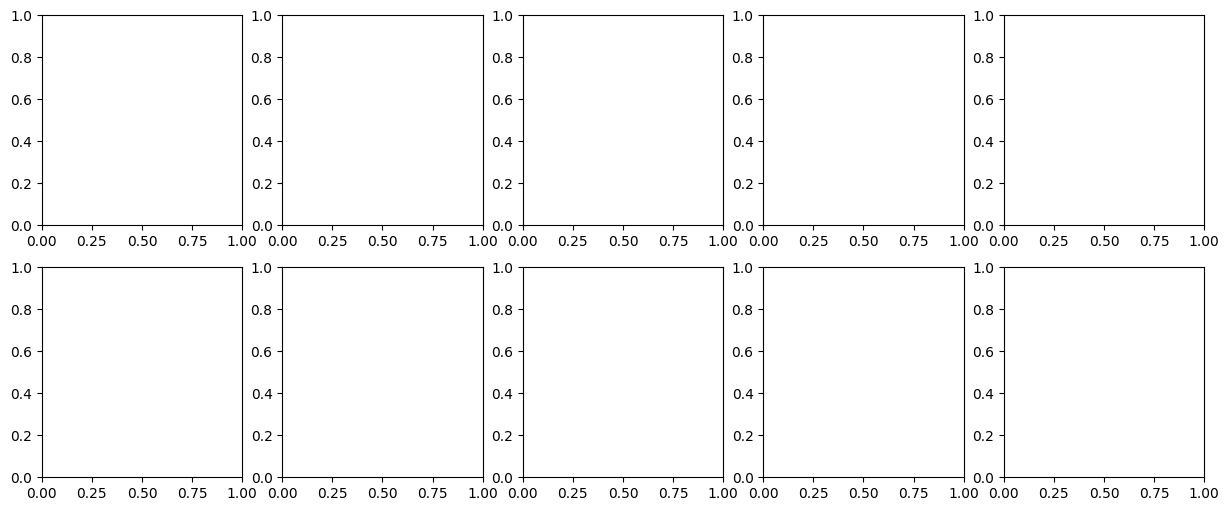

In [29]:
import json
from pathlib import Path
import matplotlib.pyplot as plt

# ---- Step 1: Load strokes from the new combined JSON file ----
combined_json_path = "wanddata_combined.json"  # Replace with your actual file name

with open(combined_json_path, "r") as f:
    file_data = json.load(f)

strokes = []
for stroke in file_data["strokes"]:
    strokes.append(stroke)

# ---- Step 2: Collect one sample per label ----
label_to_stroke = {}
for stroke in strokes:
    label = stroke["label"].lower()
    if label not in label_to_stroke:
        label_to_stroke[label] = stroke
    if len(label_to_stroke) == 10:
        break  # We only need 1 sample per class (0 to 9)

# ---- Step 3: Rasterize and display each sample ----
IMAGE_WIDTH = 32
IMAGE_HEIGHT = 32
X_RANGE = 0.6
Y_RANGE = 0.6

fig, axs = plt.subplots(2, 5, figsize=(15, 6))
axs = axs.flatten()

for idx, (label, stroke) in enumerate(sorted(label_to_stroke.items(), key=lambda x: int(x[0]))):
    points = stroke["strokePoints"]
    raster = rasterize_stroke(points, X_RANGE, Y_RANGE, IMAGE_WIDTH, IMAGE_HEIGHT)
    axs[idx].imshow(raster)
    axs[idx].axis('off')
    axs[idx].set_title(f"Label: {label}")

plt.tight_layout()
plt.show()


### 🔁 Fine-Tuning with All 10 Digit Labels

In this lab, you will fine-tune the pre-trained model using your own collected gesture data for **all 10 digits**: `0–9`.

The goal is to adapt the model to your personal drawing style while keeping the original 10-class digit classification structure.

---

#### 🖼️ Save Your Custom Images

Use your collected or augmented strokes and save them into a folder named `finetune/`.

Inside the `finetune/` folder, there should be one subfolder for each digit label:

```text
finetune/
├── 0/
├── 1/
├── 2/
├── 3/
├── 4/
├── 5/
├── 6/
├── 7/
├── 8/
└── 9/

In [28]:
import numpy as np
import tensorflow as tf

save_strokes_as_images(strokes, "finetune", IMAGE_WIDTH, IMAGE_HEIGHT, augment_count=0)

import tensorflow as tf
import numpy as np

# Step 1: Load dataset with label_mode='int' so we can remap labels manually
partial_ds = tf.keras.utils.image_dataset_from_directory(
    directory='finetune',
    labels='inferred',
    label_mode='int',  # We will map to one-hot manually
    batch_size=32,
    image_size=(IMAGE_WIDTH, IMAGE_HEIGHT),
    shuffle=True
)

# Step 2: Get actual subdirectory names
label_map = partial_ds.class_names
label_ints = [int(cls) for cls in label_map]

# Step 3: Define map function to create 10-class one-hot
def map_to_10class(x, y):
    # y is index in label_map → map to actual label
    y_real = tf.gather(label_ints, y)
    y_onehot = tf.one_hot(y_real, depth=10)
    return x, y_onehot

# Step 4: Apply mapping
finetune_ds = partial_ds.map(map_to_10class)


Found 7 files belonging to 7 classes.


### 📊 Evaluating Baseline Model on Collected Fine-Tune Data

Before fine-tuning, we evaluate the original model using the new dataset collected from your own device (as instructed in **Lab 7 Data Collection Instructions**). This helps us understand how well the pretrained model performs on your personal handwriting or gesture data.

#### 🧾 What We Do Here:

- **Generate Predictions**:
  - We feed your collected strokes (converted to images) into the pretrained model.
  - Predictions are gathered for each input sample.

- **Convert to Class Labels**:
  - Both true labels (`y_true`) and predicted outputs (`y_pred`) are converted from one-hot vectors to integer class labels using `argmax`.

- **Evaluate Performance**:
  - **Classification Report**: Shows precision, recall, and F1-score for each digit class (0–9).
  - **Confusion Matrix**: Displays where the model is getting predictions right and where it's confusing one digit for another.

---

> 🔍 This evaluation provides a baseline accuracy on your own data before any fine-tuning. It's useful for measuring improvement after adapting the model.


In [29]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

y_true = []
y_pred = []

for x_batch, y_batch in finetune_ds:
    preds = model.predict(x_batch)   # Use original model
    y_true.extend(y_batch.numpy())         # Already one-hot
    y_pred.extend(preds)            # Predicted class index

# Convert one-hot (or softmax) vectors to class indices
y_true_indices = np.argmax(y_true, axis=1)
y_pred_indices = np.argmax(y_pred, axis=1)

# Print report
print("Classification Report:")
print(classification_report(y_true_indices, y_pred_indices, digits=4))

print("Confusion Matrix:")
print(confusion_matrix(y_true_indices, y_pred_indices))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 515ms/step
Classification Report:
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000       0.0
           1     0.0000    0.0000    0.0000       1.0
           2     0.0000    0.0000    0.0000       1.0
           3     0.0000    0.0000    0.0000       1.0
           4     0.0000    0.0000    0.0000       1.0
           5     0.0000    0.0000    0.0000       1.0
           6     0.0000    0.0000    0.0000       1.0
           7     0.0000    0.0000    0.0000       1.0

    accuracy                         0.0000       7.0
   macro avg     0.0000    0.0000    0.0000       7.0
weighted avg     0.0000    0.0000    0.0000       7.0

Confusion Matrix:
[[0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0]
 [0 0 1 0 0 0 0 0]
 [0 0 0 1 0 0 0 0]
 [0 0 0 1 0 0 0 0]
 [0 0 0 1 0 0 0 0]
 [0 0 0 1 0 0 0 0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

### 🧠 Fine-Tuning Strategy: Selective Layer Training

Instead of retraining the entire model from scratch, we use **transfer learning** to adapt the pretrained model to your personal data. This involves selectively unfreezing certain layers of the model for training.

#### 🔄 Step-by-Step Strategy:

1. **Model Cloning**  
   We create a copy of the trained model to avoid altering the original. This allows comparison between the baseline and fine-tuned versions.

2. **Freeze All Layers**  
   Initially, all layers of the cloned model are frozen to preserve the pretrained weights.

3. **Unfreeze Last Convolutional Layer**  
   We only unfreeze the final `Conv2D` layer. This lets the model adjust its low-level feature extraction (e.g., edges, curves) to better suit your personalized stroke data.

4. **Unfreeze Dense (Fully Connected) Layers**  
   All `Dense` layers are unfrozen so the model can refine how it maps the learned features to class predictions based on your writing style.

---

> 🎯 This selective fine-tuning helps the model adapt efficiently with minimal data and avoids overfitting, especially when training on small, user-collected datasets.


In [30]:
import copy
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Step 1: Clone the original model
finetuned_model = tf.keras.models.clone_model(model)
finetuned_model.set_weights(model.get_weights())

# Step 2: Freeze all layers initially
for layer in finetuned_model.layers:
    layer.trainable = False

# Step 3: Unfreeze the last Conv2D layer
conv_layers = [l for l in finetuned_model.layers if isinstance(l, tf.keras.layers.Conv2D)]
if conv_layers:
    conv_layers[-1].trainable = True

# Step 4: Unfreeze all Dense layers
for layer in finetuned_model.layers:
    if isinstance(layer, tf.keras.layers.Dense):
        layer.trainable = True


### 🔧 Fine-Tuning the Model

After setting up the fine-tuning strategy (freezing and unfreezing specific layers), we now compile and train the updated model.

#### ⚙️ Compilation Settings
- **Optimizer**: Adam with a lower learning rate (`0.001`) – this smaller learning rate allows the model to make subtle adjustments to the weights without overwriting what it learned from the original dataset.
- **Loss Function**: Categorical Crossentropy – remains the same since we're still solving a multi-class classification problem.
- **Metric**: Accuracy – to track the improvement in performance during fine-tuning.

#### ⏱️ Training Phase
We train the fine-tuned model for **10 epochs** using your personally collected dataset (`finetune_ds`). Even though this dataset may be small, the selective training ensures the model adapts effectively without forgetting previously learned features.

> 🧪 You should observe an increase in classification accuracy on your own data compared to the pre-finetuned model.


In [31]:
finetuned_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),  # lower LR for fine-tuning
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

finetuned_model.fit(finetune_ds, epochs=10)


Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.0000e+00 - loss: 24.8084
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.0000e+00 - loss: 22.0780
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.0000e+00 - loss: 19.4023
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.0000e+00 - loss: 16.8843
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.0000e+00 - loss: 14.5917
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.0000e+00 - loss: 12.6864
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.0000e+00 - loss: 10.9923
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.0000e+00 - loss: 9.3704
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.2857 - loss: 7.9979
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.2857 - loss: 6.9916


### 📊 Evaluation After Fine-Tuning

After fine-tuning your model using your own collected gesture data, it’s important to evaluate how well the model has adapted.

#### 🧾 Classification Report
We use `classification_report` to compute key performance metrics for each class:
- **Precision**: Of the predicted labels, how many were correct.
- **Recall**: Of the actual labels, how many were correctly predicted.
- **F1-Score**: Harmonic mean of precision and recall.
- **Support**: Number of true instances for each label in the dataset.

This gives a detailed per-class breakdown and helps assess how well the model performs across all gesture categories.

#### 🔢 Confusion Matrix
We also generate a confusion matrix, which shows the number of correct and incorrect predictions for each class. Ideally, most values should lie on the diagonal (where predicted = actual), indicating accurate classification.

> ✅ You should observe a clear improvement in accuracy and per-class metrics compared to the pre-finetuned model. This confirms that the model has learned to better recognize your unique gesture patterns.


In [32]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Predict on finetune_ds
y_true = []
y_pred = []

for x_batch, y_batch in finetune_ds:
    preds = finetuned_model.predict(x_batch)
    y_true.extend(y_batch.numpy())         # Already one-hot
    y_pred.extend(preds)

# Convert one-hot (or softmax) vectors to class indices
y_true_indices = np.argmax(y_true, axis=1)
y_pred_indices = np.argmax(y_pred, axis=1)

# Print report
print("Classification Report:")
print(classification_report(y_true_indices, y_pred_indices, digits=4))

print("Confusion Matrix:")
print(confusion_matrix(y_true_indices, y_pred_indices))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step
Classification Report:
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000         0
           1     0.0000    0.0000    0.0000         1
           2     0.0000    0.0000    0.0000         1
           3     1.0000    1.0000    1.0000         1
           4     1.0000    1.0000    1.0000         1
           5     0.0000    0.0000    0.0000         1
           6     0.0000    0.0000    0.0000         1
           7     0.5000    1.0000    0.6667         1

    accuracy                         0.4286         7
   macro avg     0.3125    0.3750    0.3333         7
weighted avg     0.3571    0.4286    0.3810         7

Confusion Matrix:
[[0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0]
 [0 0 0 1 0 0 0 0]
 [0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 1]
 [0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 1]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

### 🚀 Deploying the Fine-Tuned Model on Arduino Nano 33 BLE

Now that you've fine-tuned your model using your own gesture data, it's time to deploy it on your Arduino Nano 33 BLE Sense and observe real-time inference results.

#### 🧪 Steps to Follow

1. **📦 Convert the Fine-Tuned Model to int8 Quantized TFLite**
   - Apply post-training integer quantization to your fine-tuned model using a representative dataset (you can reuse the one used previously).
   - Ensure input and output types are set to `tf.int8`.

2. **🔁 Generate C Source File (`.cc`)**
   - Use `xxd -i` to convert your quantized `.tflite` model into a `.cc` file:
     ```bash
     !xxd -i finetuned_quantized_model.tflite > magic_wand_model_data.cc
     ```
   - Replace the generated variable name with `g_magic_wand_model_data`.

3. **📥 Upload to Arduino IDE**
   - Copy `magic_wand_model_data.cc` into your `magic_wand` Arduino sketch folder.
   - Open and upload `magic_wand.ino` to your Arduino Nano 33 BLE Sense.

4. **📸 Collect Screenshots**
   - Perform each of your digit gestures (0–9) in front of the Arduino.
   - Open the **Serial Monitor** and observe the real-time classification results.
   - **Take a screenshot for each digit** showing the predicted result from the serial output.



# 📝 Submission Instructions for Lab 7

You are required to complete and submit the following four tasks. All Lab 7 files must be uploaded to the GitHub repository that you are maintaining for this class. Then submit the GitHub repository link, or the direct Lab 7 folder link, through the Canvas submission page for Lab 7.

---

#### ✅ Task 1: Deploy Baseline int8 Quantized Model  
- Deploy the **int8 quantized model _before_ fine-tuning** onto your Arduino Nano 33 BLE Sense.  
- Draw each digit (0–9) and capture screenshots of the **Serial Monitor** output.
- Each screenshot **must clearly show**:
  - The ASCII representation of the digit you drew.
  - The predicted digit.
  - The prediction confidence value (score).

---

#### ✅ Task 2: Collect Personal Gesture Data  
- Follow the detailed steps in the **Lab 7 Data Collection Instruction.docx** to collect your own digit gesture data using the Magic Wand interface.  
- Generate your `wanddata.json` file and use it in the notebook for fine-tuning.

---

#### ✅ Task 3: Deploy Fine-Tuned int8 Quantized Model  
- Fine-tune your model using your collected data.
- Quantize the fine-tuned model using **int8 quantization**, and deploy it on your Arduino Nano 33 BLE Sense.
- Again, draw each digit (0–9) and take **screenshots of the Serial Monitor output**.
- Each screenshot **must clearly show**:
  - The ASCII representation of the digit.
  - The predicted digit.
  - The prediction confidence value (score).

---

#### ✅ Task 4: Compare Results and Reflect  
- Compare the performance of the **baseline model (Task 1)** vs the **fine-tuned model (Task 3)**.
- Briefly explain:
  - What differences did you observe?
  - Which model performed better and why?
  - Did fine-tuning help for your specific gesture style?

---

## 📤 Final Submission

Upload all Lab 7 materials to the GitHub repository that you are maintaining for this class. Your GitHub submission should include all relevant files needed to reproduce and review your work, including:

- Your completed Jupyter notebook.
- Your collected `wanddata.json` file.
- The Arduino `.ino` file used for the **baseline int8 quantized model before fine-tuning**.
- The Arduino `.ino` file used for the **fine-tuned int8 quantized model**.
- Any generated model files, converted model files, header files, or supporting files used for deployment.
- Screenshots of the Serial Monitor outputs for digits 0–9 before fine-tuning.
- Screenshots of the Serial Monitor outputs for digits 0–9 after fine-tuning.
- A short reflection comparing the baseline and fine-tuned models. This reflection can be included either in the notebook or as a separate PDF/Markdown file.

Submit the GitHub repository link, or the direct link to your Lab 7 folder inside the repository, through the **Lab 7 submission page on Canvas**.

> 💡 *Tip:* Be sure to perform inference for all 10 digits (0–9) in both Task 1 and Task 3. Also make sure your GitHub link is accessible to the teaching team.